# AI-Powered Retail Sales Analytics and Sales Prediction

## Walmart Store Sales Forecasting - Complete Analysis & Prediction

---

**Domain:** Data Analytics using AI

**Dataset:** Walmart Store Sales Forecasting (Kaggle)

This notebook presents a complete, end-to-end analysis of Walmart's historical sales data across 45 stores and 81 departments, covering the period from February 2010 to October 2012. We build and compare multiple machine learning models to predict future weekly sales.

| File | Description |
|------|-------------|
| `train.csv` | Historical weekly sales per store-department (target: `Weekly_Sales`) |
| `test.csv` | Future weeks requiring prediction |
| `features.csv` | Store-level weekly features (economic + markdown indicators) |
| `stores.csv` | Store metadata (type and size) |
| `sampleSubmission.csv` | Expected submission format |


---
## 2. Problem Statement

Given historical weekly sales data from 45 Walmart stores (each with multiple departments), along with external features (temperature, fuel price, CPI, unemployment, and promotional markdowns), **predict future weekly sales for each store-department combination**.

This is a **regression problem** with a **temporal dimension** -- we predict future sales from past observations, making it critical to avoid data leakage through random splitting.


## 3. Objectives

1. **Explore** the dataset to understand sales patterns, seasonality, and external factor relationships
2. **Clean and preprocess** the data with a reusable pipeline
3. **Engineer features** that capture temporal and promotional signals
4. **Train and compare** 5 regression models using time-based validation
5. **Select the best model** programmatically based on actual validation metrics
6. **Generate predictions** for the test dataset
7. **Extract business insights** from the data and model


---
## 4. Setup and Data Loading


In [1]:
# -- Imports ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import sys
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# -- Paths (Robust resolution for root, notebooks/, and Google Colab) ---------
candidates = [
    '.',
    '..',
    '../..',
    os.path.join(os.path.dirname(os.getcwd()), ''),
    'walmart-recruiting-store-sales-forecasting',
    '../walmart-recruiting-store-sales-forecasting',
    '/content',
    '/content/walmart-recruiting-store-sales-forecasting',
]

DATA_DIR = None
for d in candidates:
    if os.path.exists(os.path.join(d, 'train.csv')):
        DATA_DIR = d
        break

if DATA_DIR is None:
    if 'google.colab' in sys.modules or os.path.exists('/content'):
        print('Google Colab detected. \'train.csv\' not found in /content.')
        print('Please upload your project CSV files (train.csv, test.csv, features.csv, stores.csv):')
        try:
            from google.colab import files
            uploaded = files.upload()
            DATA_DIR = '.'
        except Exception as e:
            raise FileNotFoundError('Please upload the dataset CSV files to continue.') from e
    else:
        raise FileNotFoundError(
            'Could not locate train.csv. Please ensure the CSV files are in the project folder.'
        )

MODELS_DIR = os.path.join(DATA_DIR, 'models')
OUTPUTS_DIR = os.path.join(DATA_DIR, 'outputs')
FIGURES_DIR = os.path.join(OUTPUTS_DIR, 'figures')
METRICS_DIR = os.path.join(OUTPUTS_DIR, 'metrics')
PREDICTIONS_DIR = os.path.join(OUTPUTS_DIR, 'predictions')

for d in [MODELS_DIR, FIGURES_DIR, METRICS_DIR, PREDICTIONS_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE = 42
print(f'Data directory resolved to: {os.path.abspath(DATA_DIR)}')
print('All libraries imported successfully.')


All libraries imported successfully.


In [2]:
# -- Load Datasets ------------------------------------------------------------
train_raw = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_raw = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
features_raw = pd.read_csv(os.path.join(DATA_DIR, 'features.csv'))
stores = pd.read_csv(os.path.join(DATA_DIR, 'stores.csv'))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sampleSubmission.csv'))

print("Dataset shapes:")
print(f"  train.csv:            {train_raw.shape[0]:>10,} rows x {train_raw.shape[1]} cols")
print(f"  test.csv:             {test_raw.shape[0]:>10,} rows x {test_raw.shape[1]} cols")
print(f"  features.csv:         {features_raw.shape[0]:>10,} rows x {features_raw.shape[1]} cols")
print(f"  stores.csv:           {stores.shape[0]:>10,} rows x {stores.shape[1]} cols")
print(f"  sampleSubmission.csv: {sample_sub.shape[0]:>10,} rows x {sample_sub.shape[1]} cols")


Dataset shapes:
  train.csv:               421,570 rows x 5 cols
  test.csv:                115,064 rows x 4 cols
  features.csv:              8,190 rows x 12 cols
  stores.csv:                   45 rows x 3 cols
  sampleSubmission.csv:    115,064 rows x 2 cols


### 4.1 Dataset Structure


In [3]:
# -- Inspect each dataset -----------------------------------------------------
print("TRAIN.CSV")
print(f"  Columns: {list(train_raw.columns)}")
print(f"  Date range: {train_raw['Date'].min()} to {train_raw['Date'].max()}")
print(f"  Stores: {train_raw['Store'].nunique()}, Departments: {train_raw['Dept'].nunique()}")
print(f"  Weekly_Sales range: ${train_raw['Weekly_Sales'].min():,.2f} to ${train_raw['Weekly_Sales'].max():,.2f}")
print(f"  Negative sales: {(train_raw['Weekly_Sales'] < 0).sum():,}")
print()
print("TEST.CSV")
print(f"  Columns: {list(test_raw.columns)}")
print(f"  Date range: {test_raw['Date'].min()} to {test_raw['Date'].max()}")
print(f"  Note: No Weekly_Sales column (this is what we predict)")
print()
print("FEATURES.CSV")
print(f"  Columns: {list(features_raw.columns)}")
print()
print("STORES.CSV")
print(stores.to_string(index=False))
print()
print("SAMPLE SUBMISSION")
print(f"  Columns: {list(sample_sub.columns)}")
print(f"  Id format example: {sample_sub['Id'].iloc[0]}")
print(f"  Format: Store_Dept_Date")


TRAIN.CSV
  Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']
  Date range: 2010-02-05 to 2012-10-26
  Stores: 45, Departments: 81
  Weekly_Sales range: $-4,988.94 to $693,099.36
  Negative sales: 1,285

TEST.CSV
  Columns: ['Store', 'Dept', 'Date', 'IsHoliday']
  Date range: 2012-11-02 to 2013-07-26
  Note: No Weekly_Sales column (this is what we predict)

FEATURES.CSV
  Columns: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

STORES.CSV
 Store Type   Size
     1    A 151315
     2    A 202307
     3    B  37392
     4    A 205863
     5    B  34875
     6    A 202505
     7    B  70713
     8    A 155078
     9    B 125833
    10    B 126512
    11    A 207499
    12    B 112238
    13    A 219622
    14    A 200898
    15    B 123737
    16    B  57197
    17    B  93188
    18    B 120653
    19    A 203819
    20    A 203742
    21    B 140167
    22    B 119557
    2

---
## 5. Data Quality Analysis

Check for missing values, duplicates, and data integrity.


In [4]:
# -- Missing Values -----------------------------------------------------------
print("MISSING VALUES")
print("=" * 50)
for name, df in [("train", train_raw), ("test", test_raw),
                 ("features", features_raw), ("stores", stores)]:
    missing = df.isnull().sum()
    total = missing.sum()
    print(f"\n{name}.csv (total missing: {total:,}):")
    if total == 0:
        print("  No missing values.")
    else:
        for col in missing[missing > 0].index:
            pct = missing[col] / len(df) * 100
            print(f"  {col}: {missing[col]:,} ({pct:.1f}%)")


MISSING VALUES

train.csv (total missing: 0):
  No missing values.

test.csv (total missing: 0):
  No missing values.

features.csv (total missing: 24,040):
  MarkDown1: 4,158 (50.8%)
  MarkDown2: 5,269 (64.3%)
  MarkDown3: 4,577 (55.9%)
  MarkDown4: 4,726 (57.7%)
  MarkDown5: 4,140 (50.5%)
  CPI: 585 (7.1%)
  Unemployment: 585 (7.1%)

stores.csv (total missing: 0):
  No missing values.


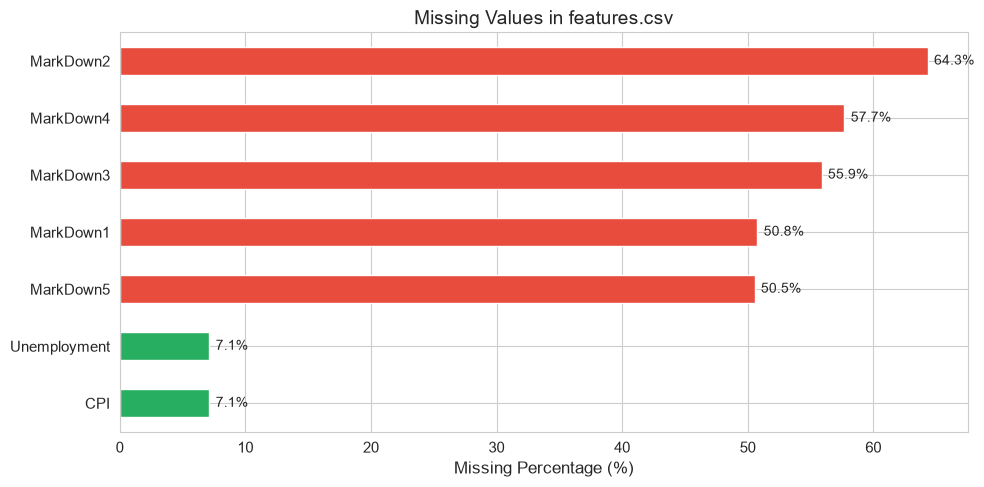

Key Observations:
- MarkDown columns: 50-64% missing (promotions started later in the timeline)
- CPI and Unemployment: ~7% missing (some stores lack economic data)
- train.csv, test.csv, stores.csv: no missing values


In [5]:
# -- Visualize Missing Values -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
missing_pct = (features_raw.isnull().sum() / len(features_raw) * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]
colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 10 else '#27ae60' for v in missing_pct.values]
missing_pct.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values in features.csv')
for i, (val, name) in enumerate(zip(missing_pct.values, missing_pct.index)):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("Key Observations:")
print("- MarkDown columns: 50-64% missing (promotions started later in the timeline)")
print("- CPI and Unemployment: ~7% missing (some stores lack economic data)")
print("- train.csv, test.csv, stores.csv: no missing values")


In [6]:
# -- Duplicates and Date Overlap -----------------------------------------------
print("DUPLICATE ROWS")
for name, df in [("train", train_raw), ("test", test_raw),
                 ("features", features_raw), ("stores", stores)]:
    print(f"  {name}.csv: {df.duplicated().sum()} duplicates")

train_dates = set(train_raw['Date'].unique())
test_dates = set(test_raw['Date'].unique())
overlap = train_dates & test_dates
print(f"\nTrain/Test date overlap: {len(overlap)} dates")
print("Train ends before test begins: clean temporal separation.")


DUPLICATE ROWS
  train.csv: 0 duplicates
  test.csv: 0 duplicates
  features.csv: 0 duplicates
  stores.csv: 0 duplicates

Train/Test date overlap: 0 dates
Train ends before test begins: clean temporal separation.


---
## 6. Data Cleaning

**Strategy:**
- **MarkDown1-5**: Fill with 0 (missing means no promotion was active)
- **CPI / Unemployment**: Forward-fill then backward-fill per store (these change slowly)
- **Dates**: Parse to datetime


In [7]:
# -- Reusable Preprocessing Functions -----------------------------------------
# These functions are used identically for train, validation, and test data.

MD_COLS = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

def clean_features(features_df):
    """Clean the features dataset: fill missing values."""
    df = features_df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    for col in MD_COLS:
        df[col] = df[col].fillna(0)
    for col in ['CPI', 'Unemployment']:
        df[col] = df.groupby('Store')[col].transform(lambda s: s.ffill().bfill())
    return df

def merge_all(base_df, features_df, stores_df):
    """Merge base (train/test) with features and stores."""
    df = base_df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    merged = df.merge(features_df, on=['Store', 'Date', 'IsHoliday'], how='left')
    merged = merged.merge(stores_df, on='Store', how='left')
    # Fill any remaining NAs from merge
    for col in MD_COLS:
        if col in merged.columns:
            merged[col] = merged[col].fillna(0)
    for col in ['CPI', 'Unemployment']:
        if col in merged.columns and merged[col].isna().any():
            merged[col] = merged.groupby('Store')[col].transform(lambda s: s.ffill().bfill())
    return merged

def add_features(df):
    """Add temporal and derived features. Uses only date-available information."""
    df = df.copy()
    # Temporal
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['Quarter'] = df['Date'].dt.quarter
    df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
    df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)
    # Derived
    df['TotalMarkDown'] = df[MD_COLS].sum(axis=1)
    df['HasMarkDown'] = (df['TotalMarkDown'] > 0).astype(int)
    # Encode store type
    type_map = {'A': 2, 'B': 1, 'C': 0}
    if 'Type' in df.columns:
        df['Type_encoded'] = df['Type'].map(type_map)
    # IsHoliday to int
    df['IsHoliday'] = df['IsHoliday'].astype(int)
    return df

FEATURE_COLS = [
    'Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'CPI', 'Unemployment', 'Size', 'Type_encoded',
    'Year', 'Month', 'WeekOfYear', 'DayOfWeek', 'Quarter',
    'IsMonthStart', 'IsMonthEnd', 'TotalMarkDown', 'HasMarkDown'
]

print("Preprocessing functions defined.")
print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")


Preprocessing functions defined.
Feature columns (23): ['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Type_encoded', 'Year', 'Month', 'WeekOfYear', 'DayOfWeek', 'Quarter', 'IsMonthStart', 'IsMonthEnd', 'TotalMarkDown', 'HasMarkDown']


In [8]:
# -- Apply Cleaning -----------------------------------------------------------
features_clean = clean_features(features_raw)
print(f"features.csv cleaned. Remaining NAs: {features_clean.isnull().sum().sum()}")


features.csv cleaned. Remaining NAs: 0


---
## 7. Dataset Merging

Merge train/test with features (on Store, Date, IsHoliday) and stores (on Store).


In [9]:
# -- Merge Training Data ------------------------------------------------------
df = merge_all(train_raw, features_clean, stores)
print(f"Merged training data: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Remaining missing values: {df.isnull().sum().sum()}")
df.head()


Merged training data: 421,570 rows x 16 cols


Remaining missing values: 0


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315


---
## 8. Exploratory Data Analysis

### 8.1 Sales Distribution


Weekly Sales Summary
  Mean:     $   15,981.26
  Median:   $    7,612.03
  Std Dev:  $   22,711.18
  Min:      $   -4,988.94
  Max:      $  693,099.36
  Skewness:       3.2620
  Negative:        1,285


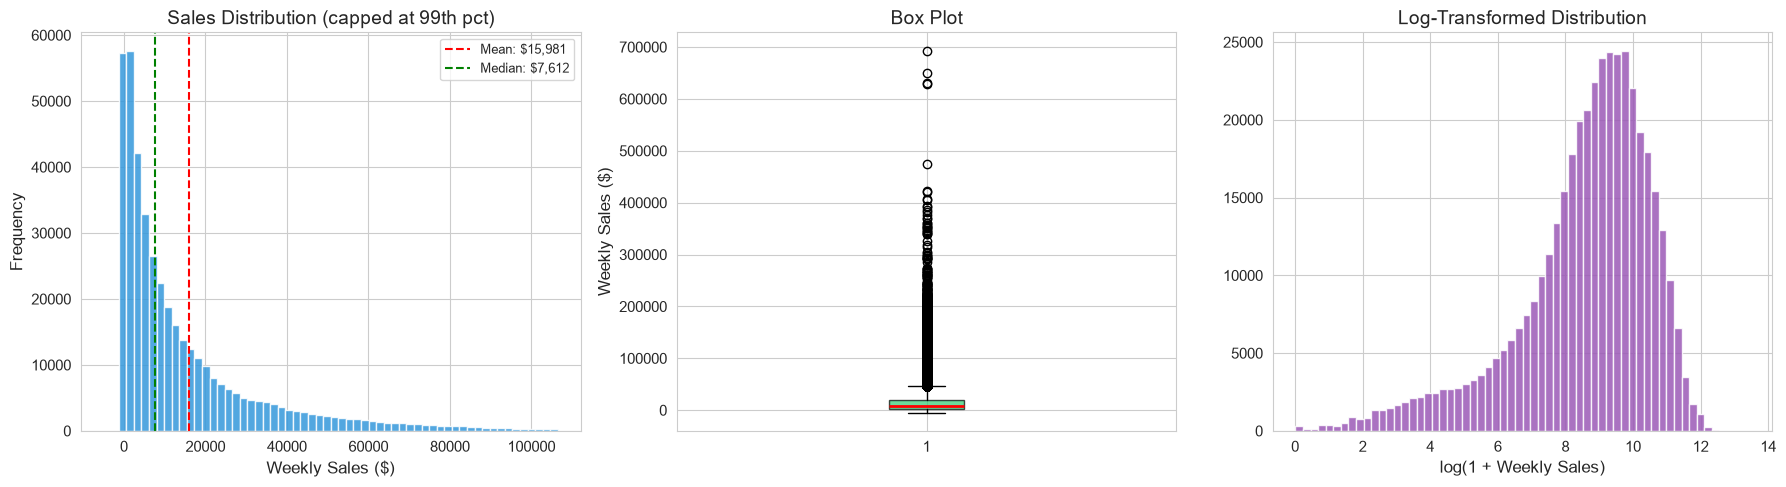


The distribution is heavily right-skewed. Median is much lower than mean,
indicating a long right tail from high-performing store-departments.


In [10]:
# -- Sales Distribution -------------------------------------------------------
sales = df['Weekly_Sales']
print("Weekly Sales Summary")
print("=" * 40)
print(f"  Mean:     ${sales.mean():>12,.2f}")
print(f"  Median:   ${sales.median():>12,.2f}")
print(f"  Std Dev:  ${sales.std():>12,.2f}")
print(f"  Min:      ${sales.min():>12,.2f}")
print(f"  Max:      ${sales.max():>12,.2f}")
print(f"  Skewness: {sales.skew():>12.4f}")
print(f"  Negative: {(sales < 0).sum():>12,}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cap = sales.quantile(0.99)
axes[0].hist(sales[sales <= cap], bins=60, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(sales.mean(), color='red', ls='--', lw=1.5, label=f'Mean: ${sales.mean():,.0f}')
axes[0].axvline(sales.median(), color='green', ls='--', lw=1.5, label=f'Median: ${sales.median():,.0f}')
axes[0].set_xlabel('Weekly Sales ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sales Distribution (capped at 99th pct)')
axes[0].legend(fontsize=9)

axes[1].boxplot(sales, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2ecc71', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Weekly Sales ($)')
axes[1].set_title('Box Plot')

positive = sales[sales > 0]
axes[2].hist(np.log1p(positive), bins=60, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[2].set_xlabel('log(1 + Weekly Sales)')
axes[2].set_title('Log-Transformed Distribution')
plt.tight_layout()
plt.show()

print("\nThe distribution is heavily right-skewed. Median is much lower than mean,")
print("indicating a long right tail from high-performing store-departments.")


### 8.2 Store-Wise Analysis


Top 5 Stores:
  1. Store 20: $301,397,792 total, $29,508 avg
  2. Store 4: $299,543,953 total, $29,161 avg
  3. Store 14: $288,999,911 total, $28,785 avg
  4. Store 13: $286,517,704 total, $27,355 avg
  5. Store 2: $275,382,441 total, $26,898 avg

Bottom 5 Stores:
  1. Store 38: $55,159,626 total, $7,492 avg
  2. Store 36: $53,412,215 total, $8,584 avg
  3. Store 5: $45,475,689 total, $5,053 avg
  4. Store 44: $43,293,088 total, $6,039 avg
  5. Store 33: $37,160,222 total, $5,728 avg


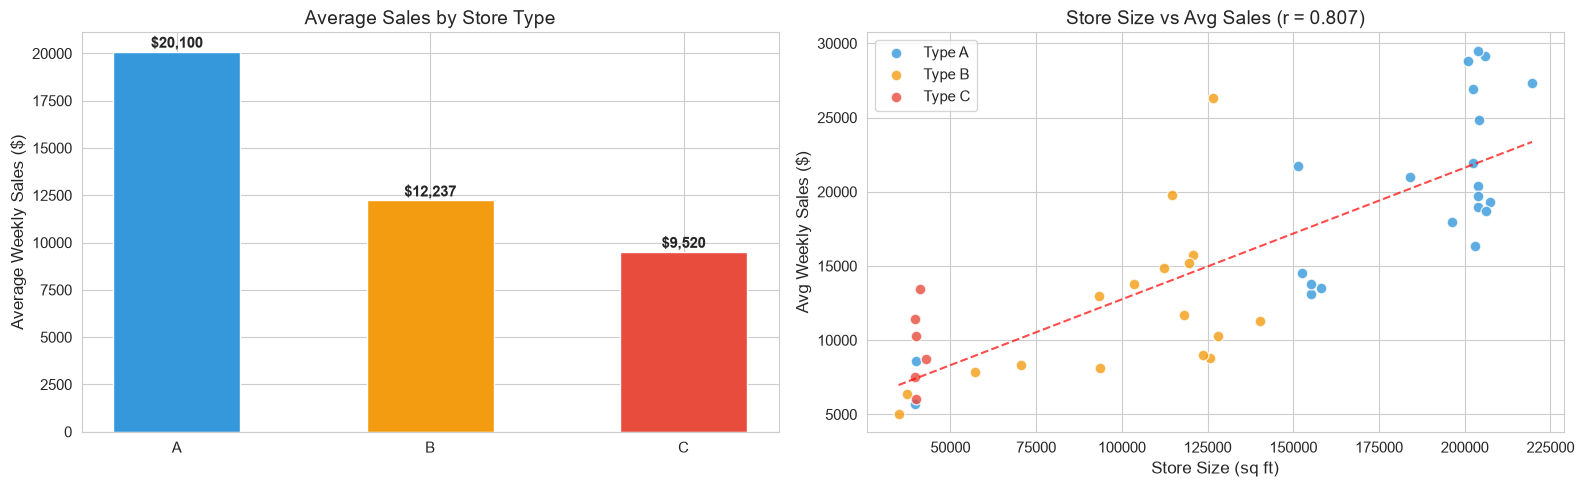


Store size shows a strong positive correlation (0.807) with average sales.


In [11]:
# -- Store Analysis -----------------------------------------------------------
store_sales = df.groupby('Store')['Weekly_Sales'].agg(['sum', 'mean']).round(2)
store_sales.columns = ['Total', 'Average']
store_sales = store_sales.sort_values('Total', ascending=False)

print("Top 5 Stores:")
for i, (s, row) in enumerate(store_sales.head().iterrows(), 1):
    print(f"  {i}. Store {s}: ${row['Total']:,.0f} total, ${row['Average']:,.0f} avg")
print("\nBottom 5 Stores:")
for i, (s, row) in enumerate(store_sales.tail().iterrows(), 1):
    print(f"  {i}. Store {s}: ${row['Total']:,.0f} total, ${row['Average']:,.0f} avg")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Sales by type
type_sales = df.groupby('Type')['Weekly_Sales'].mean().sort_values(ascending=False)
type_colors = {'A': '#3498db', 'B': '#f39c12', 'C': '#e74c3c'}
axes[0].bar(type_sales.index, type_sales.values,
            color=[type_colors[t] for t in type_sales.index], edgecolor='white', width=0.5)
axes[0].set_ylabel('Average Weekly Sales ($)')
axes[0].set_title('Average Sales by Store Type')
for i, (t, v) in enumerate(type_sales.items()):
    axes[0].text(i, v + 200, f'${v:,.0f}', ha='center', fontweight='bold')

# Size vs Sales
store_info = df.groupby('Store').agg({'Weekly_Sales': 'mean', 'Size': 'first', 'Type': 'first'}).reset_index()
for t, color in type_colors.items():
    m = store_info['Type'] == t
    axes[1].scatter(store_info[m]['Size'], store_info[m]['Weekly_Sales'], c=color, s=60, alpha=0.8, label=f'Type {t}', edgecolors='white')
z = np.polyfit(store_info['Size'], store_info['Weekly_Sales'], 1)
x_line = np.linspace(store_info['Size'].min(), store_info['Size'].max(), 100)
axes[1].plot(x_line, np.poly1d(z)(x_line), 'r--', alpha=0.7)
corr_size = store_info['Size'].corr(store_info['Weekly_Sales'])
axes[1].set_xlabel('Store Size (sq ft)')
axes[1].set_ylabel('Avg Weekly Sales ($)')
axes[1].set_title(f'Store Size vs Avg Sales (r = {corr_size:.3f})')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"\nStore size shows a strong positive correlation ({corr_size:.3f}) with average sales.")


### 8.3 Department Analysis


Total departments: 81

Top 10 Departments:
   1. Dept 92: $    483,943,342 total | $    75,205 avg
   2. Dept 95: $    449,320,163 total | $    69,824 avg
   3. Dept 38: $    393,118,137 total | $    61,091 avg
   4. Dept 72: $    305,725,152 total | $    50,567 avg
   5. Dept 90: $    291,068,464 total | $    45,232 avg
   6. Dept 40: $    288,936,022 total | $    44,901 avg
   7. Dept  2: $    280,611,174 total | $    43,607 avg
   8. Dept 91: $    216,781,706 total | $    33,688 avg
   9. Dept 13: $    197,321,570 total | $    30,664 avg
  10. Dept  8: $    194,280,781 total | $    30,191 avg


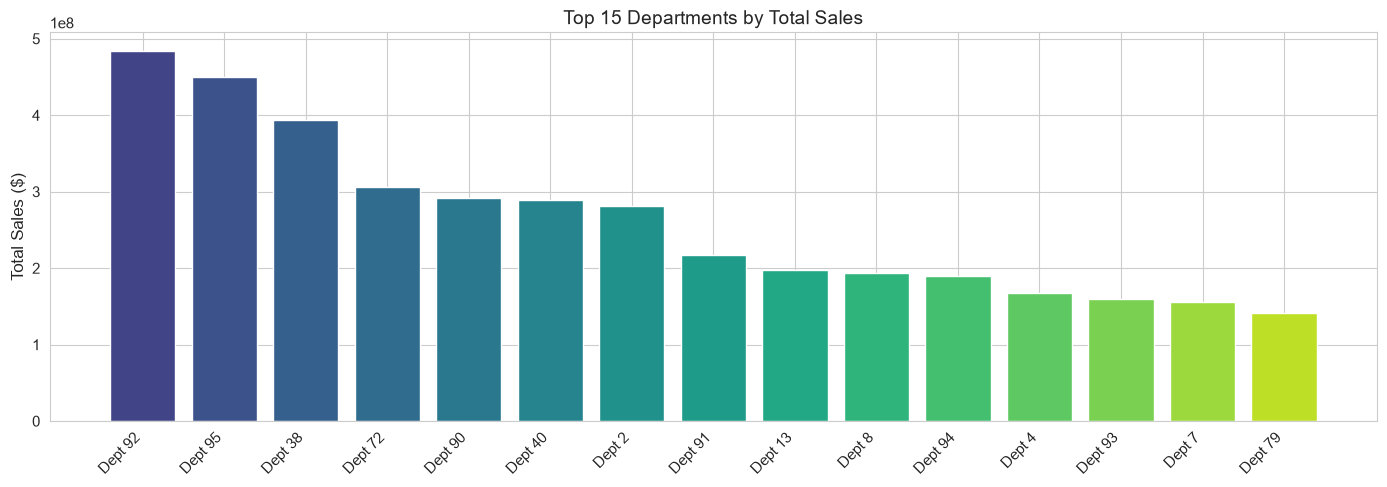

In [12]:
# -- Department Analysis ------------------------------------------------------
dept_sales = df.groupby('Dept')['Weekly_Sales'].agg(['sum', 'mean']).round(2)
dept_sales.columns = ['Total', 'Average']
dept_sales = dept_sales.sort_values('Total', ascending=False)

print(f"Total departments: {df['Dept'].nunique()}")
print("\nTop 10 Departments:")
for i, (d, row) in enumerate(dept_sales.head(10).iterrows(), 1):
    print(f"  {i:>2}. Dept {d:>2}: ${row['Total']:>15,.0f} total | ${row['Average']:>10,.0f} avg")

fig, ax = plt.subplots(figsize=(14, 5))
top15 = dept_sales.head(15).reset_index()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, 15))
ax.bar(range(15), top15['Total'], color=colors, edgecolor='white')
ax.set_xticks(range(15))
ax.set_xticklabels([f"Dept {d}" for d in top15['Dept']], rotation=45, ha='right')
ax.set_ylabel('Total Sales ($)')
ax.set_title('Top 15 Departments by Total Sales')
plt.tight_layout()
plt.show()


### 8.4 Time-Series Analysis


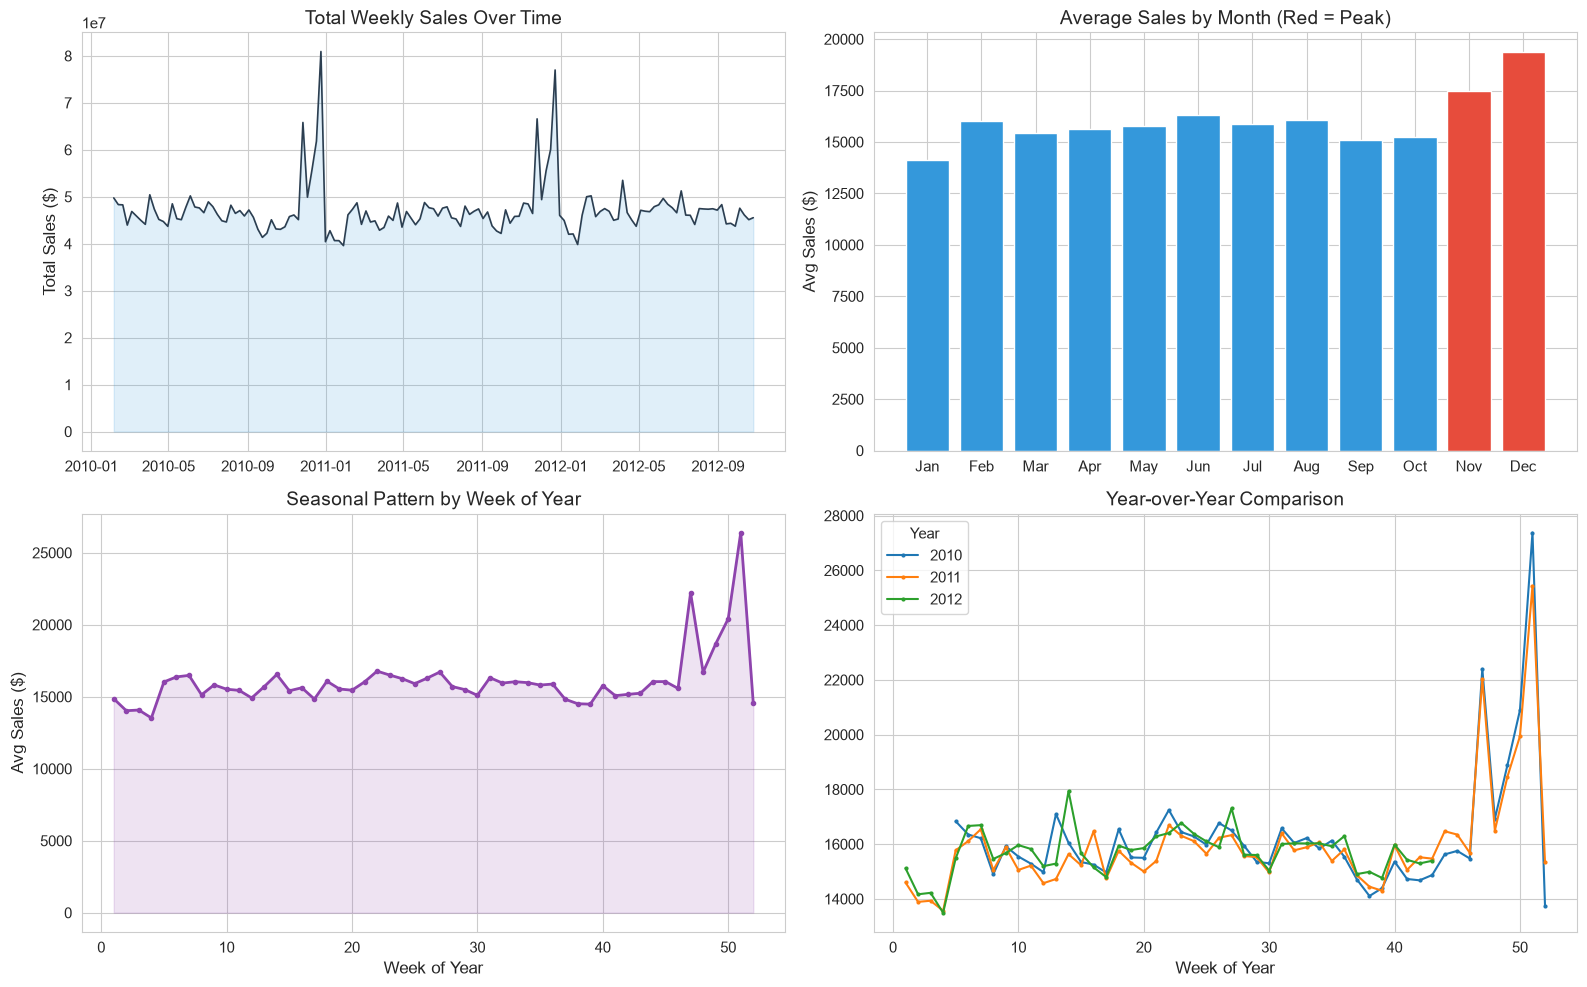

Sales peak in Dec (avg $19,356/week).
Strong yearly seasonality with Thanksgiving/Christmas spikes.


In [13]:
# -- Time-Series Analysis -----------------------------------------------------
df['Date'] = pd.to_datetime(df['Date'])
weekly_total = df.groupby('Date')['Weekly_Sales'].sum().sort_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Weekly trend
axes[0, 0].plot(weekly_total.index, weekly_total.values, color='#2c3e50', lw=1.2)
axes[0, 0].fill_between(weekly_total.index, weekly_total.values, alpha=0.15, color='#3498db')
axes[0, 0].set_title('Total Weekly Sales Over Time')
axes[0, 0].set_ylabel('Total Sales ($)')

# Monthly
month_avg = df.groupby(df['Date'].dt.month)['Weekly_Sales'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bar_colors = ['#e74c3c' if m in [11,12] else '#3498db' for m in range(1,13)]
axes[0, 1].bar(range(1,13), month_avg.values, color=bar_colors, edgecolor='white')
axes[0, 1].set_xticks(range(1,13))
axes[0, 1].set_xticklabels(month_names)
axes[0, 1].set_title('Average Sales by Month (Red = Peak)')
axes[0, 1].set_ylabel('Avg Sales ($)')

# Seasonal pattern
woy_avg = df.groupby(df['Date'].dt.isocalendar().week.astype(int))['Weekly_Sales'].mean().sort_index()
axes[1, 0].plot(woy_avg.index, woy_avg.values, color='#8e44ad', lw=2, marker='o', ms=3)
axes[1, 0].fill_between(woy_avg.index, woy_avg.values, alpha=0.15, color='#8e44ad')
axes[1, 0].set_title('Seasonal Pattern by Week of Year')
axes[1, 0].set_xlabel('Week of Year')
axes[1, 0].set_ylabel('Avg Sales ($)')

# Year over year
for year in sorted(df['Date'].dt.year.unique()):
    yd = df[df['Date'].dt.year == year]
    yearly = yd.groupby(yd['Date'].dt.isocalendar().week.astype(int))['Weekly_Sales'].mean().sort_index()
    axes[1, 1].plot(yearly.index, yearly.values, lw=1.5, marker='o', ms=2, label=str(year))
axes[1, 1].set_title('Year-over-Year Comparison')
axes[1, 1].set_xlabel('Week of Year')
axes[1, 1].legend(title='Year')

plt.tight_layout()
plt.show()

peak_month = month_avg.idxmax()
print(f"Sales peak in {month_names[peak_month-1]} (avg ${month_avg.max():,.0f}/week).")
print("Strong yearly seasonality with Thanksgiving/Christmas spikes.")


### 8.5 Holiday Analysis


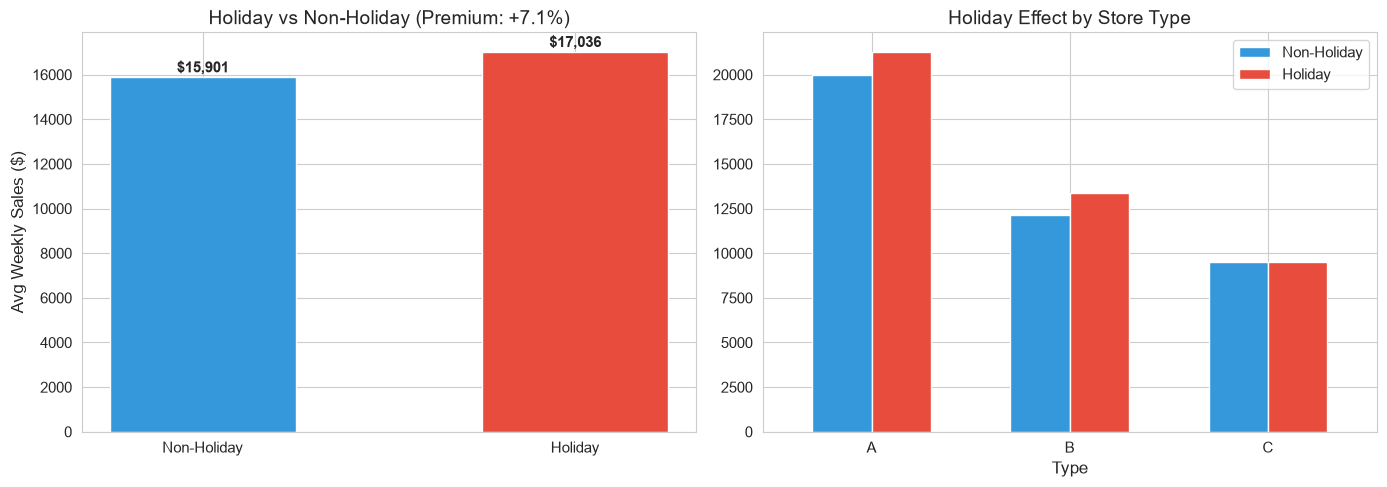

Holiday weeks average $17,036 vs $15,901 (+7.1%).


In [14]:
# -- Holiday vs Non-Holiday ---------------------------------------------------
hol_avg = df[df['IsHoliday'] == True]['Weekly_Sales'].mean()
non_hol_avg = df[df['IsHoliday'] == False]['Weekly_Sales'].mean()
pct_diff = ((hol_avg - non_hol_avg) / non_hol_avg) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(['Non-Holiday', 'Holiday'], [non_hol_avg, hol_avg],
                   color=['#3498db', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_ylabel('Avg Weekly Sales ($)')
axes[0].set_title(f'Holiday vs Non-Holiday (Premium: {pct_diff:+.1f}%)')
for bar, val in zip(bars, [non_hol_avg, hol_avg]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'${val:,.0f}', ha='center', fontweight='bold')

hol_by_type = df.pivot_table(values='Weekly_Sales', index='Type',
                              columns='IsHoliday', aggfunc='mean')
hol_by_type.columns = ['Non-Holiday', 'Holiday']
hol_by_type.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'],
                 edgecolor='white', width=0.6)
axes[1].set_title('Holiday Effect by Store Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print(f"Holiday weeks average ${hol_avg:,.0f} vs ${non_hol_avg:,.0f} ({pct_diff:+.1f}%).")


### 8.6 Correlation Analysis


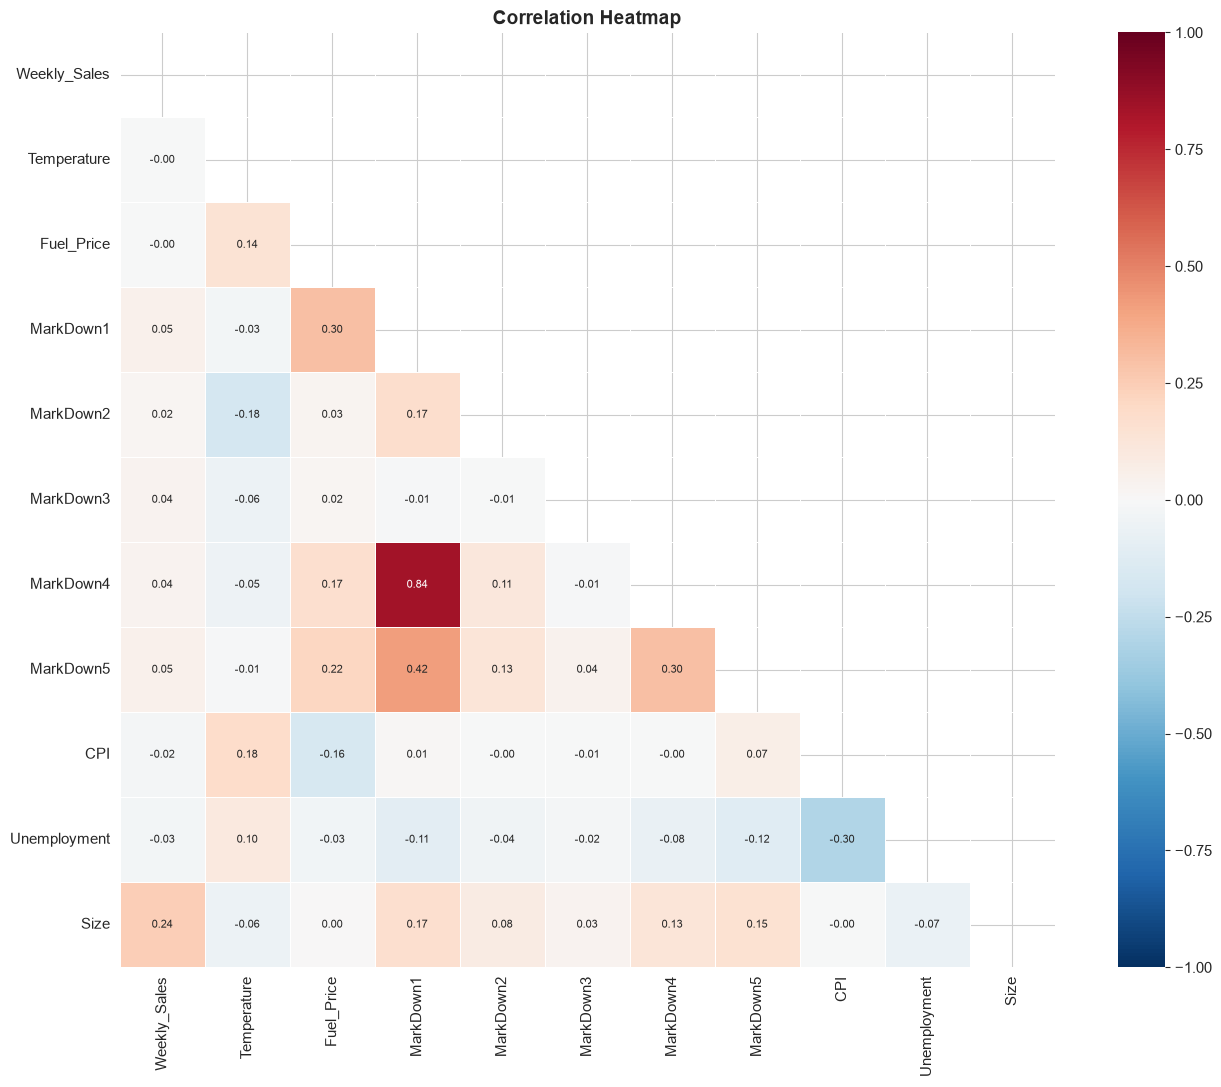

Top correlations with Weekly_Sales:
  Size                : +0.2438
  MarkDown5           : +0.0505
  MarkDown1           : +0.0472
  MarkDown3           : +0.0386
  MarkDown4           : +0.0375
  Unemployment        : -0.0259
  CPI                 : -0.0209
  MarkDown2           : +0.0207
  Temperature         : -0.0023
  Fuel_Price          : -0.0001


In [15]:
# -- Correlation Heatmap ------------------------------------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_cols = [c for c in numeric_cols if c not in ['Store', 'Dept']]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

target_corr = corr_matrix['Weekly_Sales'].drop('Weekly_Sales').abs().sort_values(ascending=False)
print("Top correlations with Weekly_Sales:")
for feat, val in target_corr.head(10).items():
    sign = "+" if corr_matrix.loc[feat, 'Weekly_Sales'] > 0 else "-"
    print(f"  {feat:20s}: {sign}{val:.4f}")


---
## 9. Feature Engineering

All features are created using `add_features()` defined earlier. This ensures the **exact same logic** is applied to training, validation, and test data.

**Temporal features:** Year, Month, WeekOfYear, DayOfWeek, Quarter, IsMonthStart, IsMonthEnd

**Derived features:** TotalMarkDown, HasMarkDown, Type_encoded


In [16]:
# -- Apply Feature Engineering ------------------------------------------------
df = add_features(df)
print(f"Final training dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Missing values: {df[FEATURE_COLS].isnull().sum().sum()}")


Final training dataset: 421,570 rows x 26 cols
Features (23): ['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Type_encoded', 'Year', 'Month', 'WeekOfYear', 'DayOfWeek', 'Quarter', 'IsMonthStart', 'IsMonthEnd', 'TotalMarkDown', 'HasMarkDown']
Missing values: 0


---
## 10. Time-Based Train/Validation Split

### Why Time-Based Validation?

This is a **sales forecasting** problem. In production, we predict *future* sales from *past* data. Random splitting would let the model see future patterns during training, causing **data leakage** and overly optimistic metrics.

**Split point:** 2012-07-01
- **Training:** Feb 2010 - Jun 2012 (~85%)
- **Validation:** Jul 2012 - Oct 2012 (~15%)


In [17]:
# -- Time-Based Split ---------------------------------------------------------
SPLIT_DATE = pd.to_datetime('2012-07-01')

X = df[FEATURE_COLS].copy()
y = df['Weekly_Sales'].copy()
date_series = df['Date'].copy()

train_mask = date_series < SPLIT_DATE
val_mask = date_series >= SPLIT_DATE

X_train, X_val = X[train_mask], X[val_mask]
y_train, y_val = y[train_mask], y[val_mask]

print(f"Training:   {X_train.shape[0]:,} rows ({date_series[train_mask].min().date()} -> {date_series[train_mask].max().date()})")
print(f"Validation: {X_val.shape[0]:,} rows ({date_series[val_mask].min().date()} -> {date_series[val_mask].max().date()})")
print(f"Split ratio: {X_train.shape[0]/len(X)*100:.1f}% / {X_val.shape[0]/len(X)*100:.1f}%")


Training:   371,242 rows (2010-02-05 -> 2012-06-29)
Validation: 50,328 rows (2012-07-06 -> 2012-10-26)
Split ratio: 88.1% / 11.9%


---
## 11. Model Training

We train 5 models and store them for comparison:
1. Naive Mean Baseline
2. Linear Regression
3. Random Forest
4. HistGradientBoosting
5. XGBoost


In [18]:
# -- Model 1: Naive Mean Baseline ---------------------------------------------
print("Training Naive Mean Baseline...")

class NaiveMeanBaseline:
    def __init__(self):
        self.means = {}
        self.global_mean = 0
    def fit(self, X, y):
        temp = X[['Store', 'Dept']].copy()
        temp['y'] = y.values
        self.means = temp.groupby(['Store', 'Dept'])['y'].mean().to_dict()
        self.global_mean = y.mean()
        return self
    def predict(self, X):
        return np.array([self.means.get((r['Store'], r['Dept']), self.global_mean)
                         for _, r in X[['Store', 'Dept']].iterrows()])

baseline_model = NaiveMeanBaseline()
baseline_model.fit(X_train, y_train)
print("  Done.")


Training Naive Mean Baseline...
  Done.


In [19]:
# -- Model 2: Linear Regression -----------------------------------------------
print("Training Linear Regression...")
scaler = StandardScaler()
non_id = [c for c in FEATURE_COLS if c not in ['Store', 'Dept']]

X_train_sc = X_train.copy()
X_train_sc[non_id] = scaler.fit_transform(X_train[non_id])
X_val_sc = X_val.copy()
X_val_sc[non_id] = scaler.transform(X_val[non_id])

lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)
print("  Done.")


Training Linear Regression...


  Done.


In [20]:
# -- Model 3: Random Forest ---------------------------------------------------
print("Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=15, min_samples_leaf=5,
    n_jobs=-1, random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)
print("  Done.")


Training Random Forest...


  Done.


In [21]:
# -- Model 4: HistGradientBoosting --------------------------------------------
print("Training HistGradientBoosting...")
hgb_model = HistGradientBoostingRegressor(
    max_iter=200, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE
)
hgb_model.fit(X_train, y_train)
print("  Done.")


Training HistGradientBoosting...


  Done.


In [22]:
# -- Model 5: XGBoost ---------------------------------------------------------
print("Training XGBoost...")
xgb_model = XGBRegressor(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train, y_train)
print("  Done.")
print("\nAll 5 models trained successfully!")


Training XGBoost...


  Done.

All 5 models trained successfully!


---
## 12. Model Evaluation

Evaluate all models on the validation set using MAE, RMSE, R-squared, and MAPE.

We prioritize **RMSE** as the primary selection metric because:
- It penalizes large errors more heavily than MAE
- Large prediction errors are costly for inventory/staffing in retail
- It is expressed in dollars, making it directly interpretable


In [23]:
# -- Evaluation Function ------------------------------------------------------
def compute_mape(y_true, y_pred, threshold=100):
    yt, yp = np.array(y_true), np.array(y_pred)
    mask = np.abs(yt) >= threshold
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = compute_mape(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
            'R2': round(r2, 4), 'MAPE': round(mape, 2)}

# -- Generate Predictions and Evaluate ----------------------------------------
model_names = ['Naive Mean Baseline', 'Linear Regression', 'Random Forest',
               'HistGradientBoosting', 'XGBoost']
model_objects = [baseline_model, lr_model, rf_model, hgb_model, xgb_model]

# Predictions: LR uses scaled features, others use raw
val_preds = {}
val_preds['Naive Mean Baseline'] = baseline_model.predict(X_val)
val_preds['Linear Regression'] = lr_model.predict(X_val_sc)
val_preds['Random Forest'] = rf_model.predict(X_val)
val_preds['HistGradientBoosting'] = hgb_model.predict(X_val)
val_preds['XGBoost'] = xgb_model.predict(X_val)

results = [evaluate(name, y_val, val_preds[name]) for name in model_names]
comparison_df = pd.DataFrame(results)

print("=" * 75)
print("MODEL COMPARISON (Validation Set)")
print("=" * 75)
print(comparison_df.to_string(index=False))
print("=" * 75)


MODEL COMPARISON (Validation Set)
               Model      MAE     RMSE     R2   MAPE
 Naive Mean Baseline  2495.09  5080.62 0.9465  39.77
   Linear Regression 14639.81 20963.37 0.0893 711.36
       Random Forest  2075.79  4005.37 0.9668  29.84
HistGradientBoosting  3516.35  5859.75 0.9288 105.55
             XGBoost  2547.69  4261.48 0.9624  71.90


---
## 13. Model Comparison


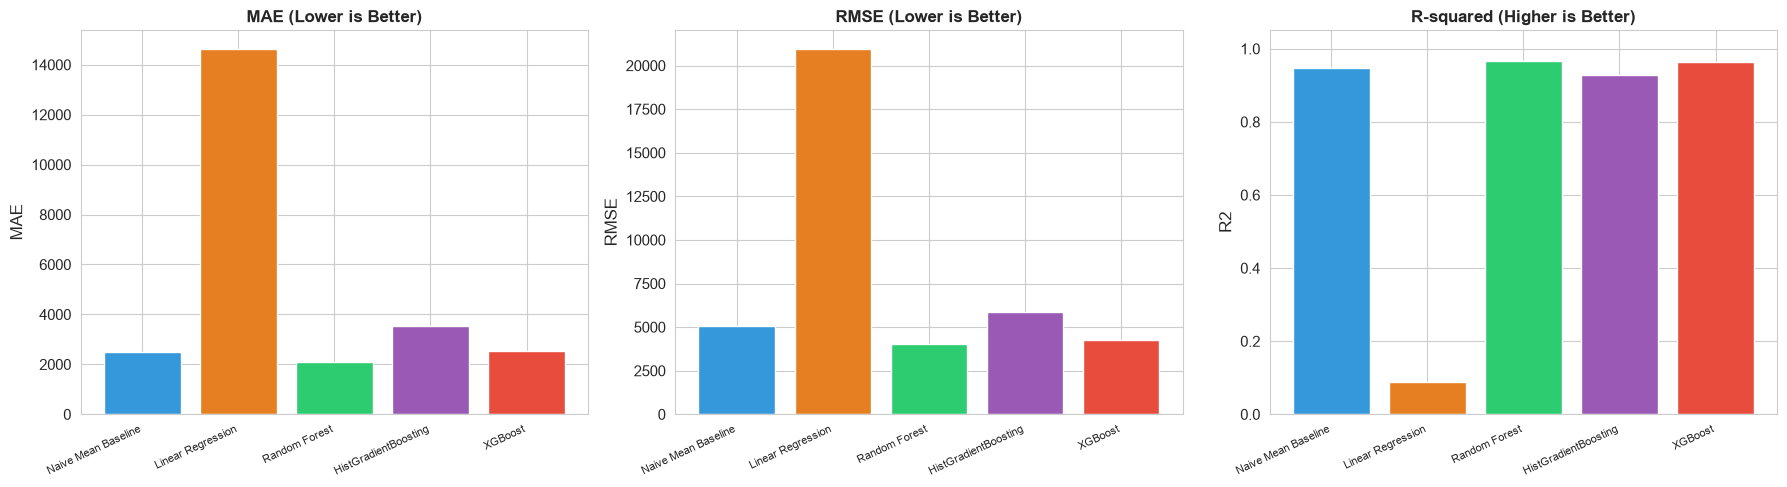

Model comparison saved to outputs/metrics/model_comparison.csv


In [24]:
# -- Comparison Charts --------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = range(len(model_names))
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#e74c3c']

for ax, metric, title in zip(axes, ['MAE', 'RMSE', 'R2'],
    ['MAE (Lower is Better)', 'RMSE (Lower is Better)', 'R-squared (Higher is Better)']):
    vals = comparison_df[metric].values
    ax.bar(x, vals, color=colors, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=8)
    if metric == 'R2':
        ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Save comparison
comparison_df.to_csv(os.path.join(METRICS_DIR, 'model_comparison.csv'), index=False)
print("Model comparison saved to outputs/metrics/model_comparison.csv")


---
## 14. Final Model Selection

The final model is selected **programmatically** based on the lowest RMSE on the validation set. No model is assumed to be best in advance.


In [25]:
# -- Select Final Model (programmatic, not hardcoded) -------------------------
best_idx = comparison_df['RMSE'].idxmin()
best_model_name = comparison_df.loc[best_idx, 'Model']

# Map name to model object
name_to_model = dict(zip(model_names, model_objects))
final_model = name_to_model[best_model_name]

# For prediction, we also need to know if the model needs scaled features
needs_scaling = (best_model_name == 'Linear Regression')

print(f"FINAL MODEL SELECTED: {best_model_name}")
print(f"  MAE:  ${comparison_df.loc[best_idx, 'MAE']:,.2f}")
print(f"  RMSE: ${comparison_df.loc[best_idx, 'RMSE']:,.2f}")
print(f"  R2:   {comparison_df.loc[best_idx, 'R2']}")
print(f"  MAPE: {comparison_df.loc[best_idx, 'MAPE']}%")
print(f"\nAll downstream predictions will use: final_model.predict()")


FINAL MODEL SELECTED: Random Forest
  MAE:  $2,075.79
  RMSE: $4,005.37
  R2:   0.9668
  MAPE: 29.84%

All downstream predictions will use: final_model.predict()


---
## 15. Feature Importance / Explainability

Feature importance is computed for the **actual selected final model**, not a hardcoded model.

We use `permutation_importance` as a model-agnostic approach that works consistently across all model types.

> **Note:** Feature importance indicates *predictive usefulness* and does not prove causation.


Computing feature importance for: Random Forest


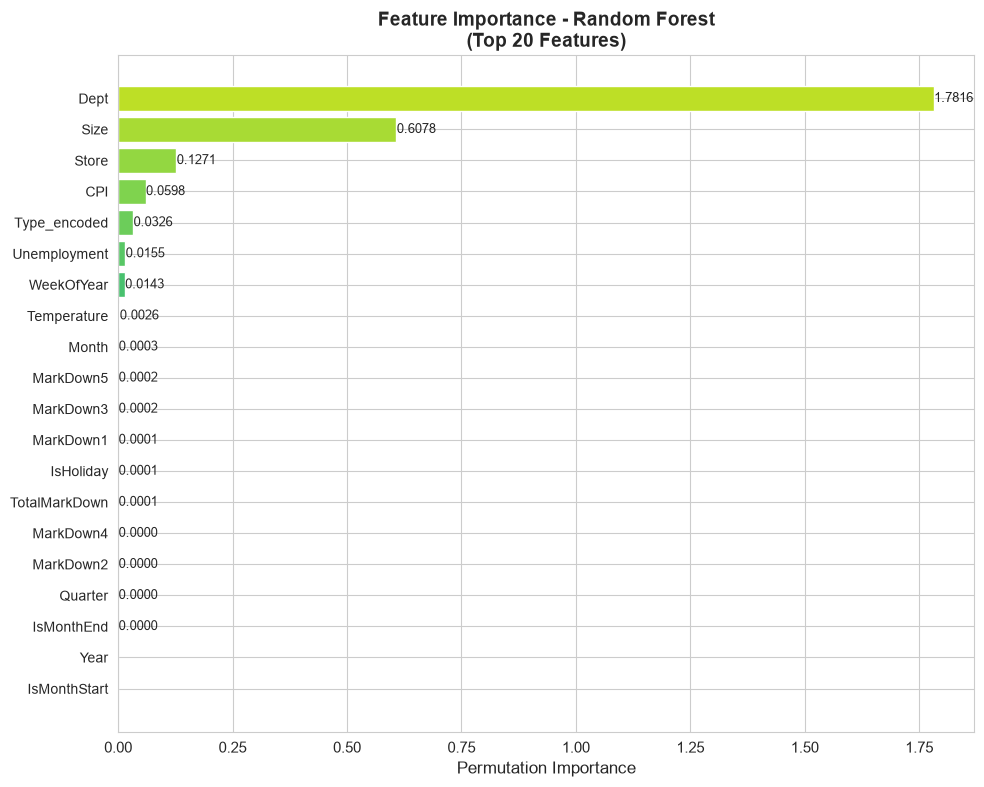


Top 10 Features for Random Forest:
   1. Dept                : 1.7816
   2. Size                : 0.6078
   3. Store               : 0.1271
   4. CPI                 : 0.0598
   5. Type_encoded        : 0.0326
   6. Unemployment        : 0.0155
   7. WeekOfYear          : 0.0143
   8. Temperature         : 0.0026
   9. Month               : 0.0003
  10. MarkDown5           : 0.0002

Feature importance shows predictive usefulness, not causal effect.


In [26]:
# -- Feature Importance (for the actual final model) --------------------------
print(f"Computing feature importance for: {best_model_name}")

# Use permutation importance (works for any model)
if needs_scaling:
    perm_result = permutation_importance(final_model, X_val_sc, y_val,
                                         n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
else:
    perm_result = permutation_importance(final_model, X_val, y_val,
                                         n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)

feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': perm_result.importances_mean
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(feat_imp))
top = feat_imp.head(top_n)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
ax.barh(range(top_n), top['Importance'].values[::-1], color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top['Feature'].values[::-1], fontsize=10)
ax.set_xlabel('Permutation Importance')
ax.set_title(f'Feature Importance - {best_model_name}\n(Top {top_n} Features)', fontsize=14, fontweight='bold')
for i, val in enumerate(top['Importance'].values[::-1]):
    if val > 0:
        ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nTop 10 Features for {best_model_name}:")
for i, (_, row) in enumerate(feat_imp.head(10).iterrows(), 1):
    print(f"  {i:>2}. {row['Feature']:20s}: {row['Importance']:.4f}")
print("\nFeature importance shows predictive usefulness, not causal effect.")


---
## 16. Validation Predictions - Actual vs Predicted

Detailed analysis of the final model's performance on the held-out validation set.


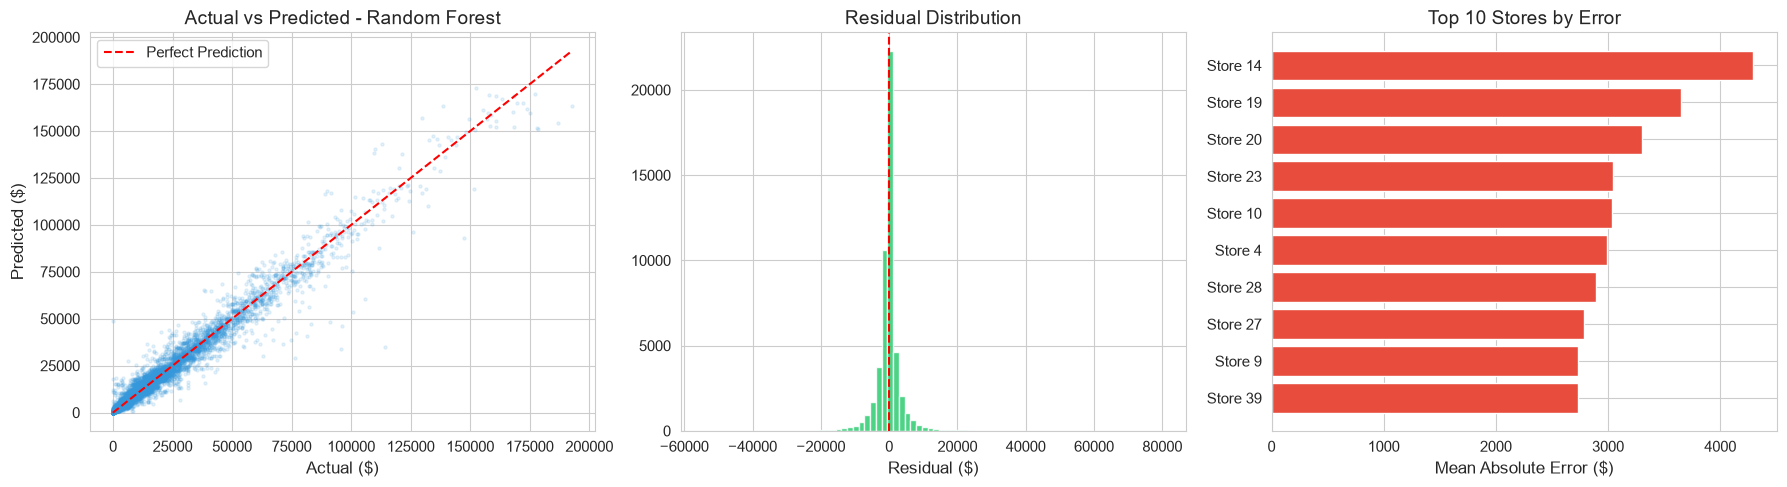

Validation Metrics for Random Forest:
  MAE:  $2,075.79
  RMSE: $4,005.37
  R2:   0.9668
  MAPE: 29.84%

Residual mean: $-203.15 (should be near 0)
Residual std:  $4,000.22


In [27]:
# -- Actual vs Predicted Analysis ----------------------------------------------
best_preds = val_preds[best_model_name]
y_val_arr = np.array(y_val)
residuals = y_val_arr - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter (sample for speed)
n = len(y_val_arr)
if n > 10000:
    idx = np.random.RandomState(42).choice(n, 10000, replace=False)
    yt_s, yp_s = y_val_arr[idx], best_preds[idx]
else:
    yt_s, yp_s = y_val_arr, best_preds
axes[0].scatter(yt_s, yp_s, alpha=0.12, s=5, color='#3498db')
lim = [min(yt_s.min(), yp_s.min()), max(yt_s.max(), yp_s.max())]
axes[0].plot(lim, lim, 'r--', lw=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual ($)')
axes[0].set_ylabel('Predicted ($)')
axes[0].set_title(f'Actual vs Predicted - {best_model_name}')
axes[0].legend()

# Residual distribution
axes[1].hist(residuals, bins=80, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', ls='--', lw=1.5)
axes[1].set_xlabel('Residual ($)')
axes[1].set_title('Residual Distribution')

# Error by store
abs_err_by_store = pd.DataFrame({'Store': X_val['Store'].values, 'AbsErr': np.abs(residuals)})
store_err = abs_err_by_store.groupby('Store')['AbsErr'].mean().sort_values(ascending=False).head(10)
axes[2].barh(range(len(store_err)), store_err.values, color='#e74c3c', edgecolor='white')
axes[2].set_yticks(range(len(store_err)))
axes[2].set_yticklabels([f"Store {s}" for s in store_err.index])
axes[2].set_xlabel('Mean Absolute Error ($)')
axes[2].set_title('Top 10 Stores by Error')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Validation Metrics for {best_model_name}:")
print(f"  MAE:  ${mean_absolute_error(y_val, best_preds):,.2f}")
print(f"  RMSE: ${np.sqrt(mean_squared_error(y_val, best_preds)):,.2f}")
print(f"  R2:   {r2_score(y_val, best_preds):.4f}")
print(f"  MAPE: {compute_mape(y_val, best_preds):.2f}%")
print(f"\nResidual mean: ${residuals.mean():,.2f} (should be near 0)")
print(f"Residual std:  ${residuals.std():,.2f}")


---
## 17. Final Model Training and Saving

Retrain the selected model on the **full** training dataset (train + validation) for maximum performance, then save.


In [28]:
# -- Retrain on Full Data and Save -------------------------------------------
print(f"Retraining {best_model_name} on full dataset ({len(X):,} rows)...")

if best_model_name == 'Naive Mean Baseline':
    final_model.fit(X, y)
elif best_model_name == 'Linear Regression':
    X_full_sc = X.copy()
    scaler_full = StandardScaler()
    X_full_sc[non_id] = scaler_full.fit_transform(X[non_id])
    final_model.fit(X_full_sc, y)
    joblib.dump(scaler_full, os.path.join(MODELS_DIR, 'preprocessor.pkl'))
    print("  Scaler saved to models/preprocessor.pkl")
else:
    final_model.fit(X, y)

# Save model and feature columns
joblib.dump(final_model, os.path.join(MODELS_DIR, 'final_model.pkl'))
joblib.dump(FEATURE_COLS, os.path.join(MODELS_DIR, 'feature_columns.pkl'))
print(f"  Model saved to models/final_model.pkl")
print(f"  Feature columns saved to models/feature_columns.pkl")


Retraining Random Forest on full dataset (421,570 rows)...


  Model saved to models/final_model.pkl
  Feature columns saved to models/feature_columns.pkl


---
## 18. Test Dataset Prediction

Apply the **exact same** preprocessing and feature engineering pipeline to `test.csv`, then generate predictions using `final_model`.


In [29]:
# -- Predict on test.csv ------------------------------------------------------
print("Preparing test data with identical pipeline...")

test_merged = merge_all(test_raw, features_clean, stores)
test_merged = add_features(test_merged)

X_test = test_merged[FEATURE_COLS].copy()
print(f"Test feature matrix: {X_test.shape[0]:,} rows x {X_test.shape[1]} cols")
print(f"Missing values: {X_test.isnull().sum().sum()}")

# Handle any remaining NAs
X_test = X_test.fillna(0)

# Apply scaling if needed
if needs_scaling:
    X_test_pred = X_test.copy()
    X_test_pred[non_id] = scaler_full.transform(X_test[non_id])
else:
    X_test_pred = X_test

test_predictions = final_model.predict(X_test_pred)
print(f"Generated {len(test_predictions):,} predictions.")
print(f"Prediction range: ${test_predictions.min():,.2f} to ${test_predictions.max():,.2f}")
print(f"Prediction mean: ${test_predictions.mean():,.2f}")


Preparing test data with identical pipeline...
Test feature matrix: 115,064 rows x 23 cols
Missing values: 0


Generated 115,064 predictions.
Prediction range: $-180.47 to $429,309.10
Prediction mean: $16,161.77


In [30]:
# -- Save Walmart_Sales_Predictions.csv ----------------------------------------
pred_df = test_merged[['Store', 'Dept', 'Date']].copy()
pred_df['Weekly_Sales'] = test_predictions.round(2)
pred_path = os.path.join(PREDICTIONS_DIR, 'Walmart_Sales_Predictions.csv')
pred_df.to_csv(pred_path, index=False)
print(f"Predictions saved to: {pred_path}")
print(f"Shape: {pred_df.shape}")
pred_df.head(10)


Predictions saved to: C:\Users\Asus\Downloads\walmart-recruiting-store-sales-forecasting\outputs\predictions\Walmart_Sales_Predictions.csv
Shape: (115064, 4)


,Store,Dept,Date,Weekly_Sales
0,1,1,2012-11-02,28250.07
1,1,1,2012-11-09,19112.63
2,1,1,2012-11-16,18949.18
3,1,1,2012-11-23,20071.80
4,1,1,2012-11-30,19919.47
5,1,1,2012-12-07,32497.94
6,1,1,2012-12-14,40720.20
7,1,1,2012-12-21,48064.74
8,1,1,2012-12-28,18643.25
9,1,1,2013-01-04,18451.38


---
## 19. Submission File

Generate a submission file matching the `sampleSubmission.csv` format: `Id` (Store_Dept_Date) and `Weekly_Sales`.


In [31]:
# -- Generate Submission File --------------------------------------------------
sub_df = test_merged[['Store', 'Dept', 'Date']].copy()
sub_df['Date_str'] = sub_df['Date'].dt.strftime('%Y-%m-%d')
sub_df['Id'] = sub_df['Store'].astype(str) + '_' + sub_df['Dept'].astype(str) + '_' + sub_df['Date_str']
sub_df['Weekly_Sales'] = test_predictions.round(2)

submission = sub_df[['Id', 'Weekly_Sales']]
sub_path = os.path.join(PREDICTIONS_DIR, 'walmart_submission.csv')
submission.to_csv(sub_path, index=False)

print(f"Submission file saved to: {sub_path}")
print(f"Shape: {submission.shape}")
print(f"\nSample Submission format check:")
print(f"  Our columns: {list(submission.columns)}")
print(f"  Expected:    {list(sample_sub.columns)}")
print(f"  Row count match: {len(submission) == len(sample_sub)}")
submission.head()


Submission file saved to: C:\Users\Asus\Downloads\walmart-recruiting-store-sales-forecasting\outputs\predictions\walmart_submission.csv
Shape: (115064, 2)

Sample Submission format check:
  Our columns: ['Id', 'Weekly_Sales']
  Expected:    ['Id', 'Weekly_Sales']
  Row count match: True


,Id,Weekly_Sales
0,1_1_2012-11-02,28250.07
1,1_1_2012-11-09,19112.63
2,1_1_2012-11-16,18949.18
3,1_1_2012-11-23,20071.80
4,1_1_2012-11-30,19919.47


---
## 20. Manual Sales Prediction Example

Demonstrates using `final_model` with the same preprocessing pipeline. The prediction value below is model-generated, not hard-coded.


In [32]:
# -- Manual Prediction Example ------------------------------------------------
def predict_single(store, dept, date_str, is_holiday=False,
                   temperature=60.0, fuel_price=3.5, cpi=220.0, unemployment=6.5,
                   md1=0, md2=0, md3=0, md4=0, md5=0):
    """Predict weekly sales using final_model with identical preprocessing."""
    date = pd.to_datetime(date_str)
    store_row = stores[stores['Store'] == store]
    type_map = {'A': 2, 'B': 1, 'C': 0}
    if len(store_row) > 0:
        type_enc = type_map.get(store_row.iloc[0]['Type'], 1)
        size = store_row.iloc[0]['Size']
    else:
        type_enc, size = 1, 130000

    row = pd.DataFrame([{
        'Store': store, 'Dept': dept, 'IsHoliday': int(is_holiday),
        'Temperature': temperature, 'Fuel_Price': fuel_price,
        'MarkDown1': md1, 'MarkDown2': md2, 'MarkDown3': md3,
        'MarkDown4': md4, 'MarkDown5': md5,
        'CPI': cpi, 'Unemployment': unemployment,
        'Size': size, 'Type_encoded': type_enc,
        'Year': date.year, 'Month': date.month,
        'WeekOfYear': int(date.isocalendar().week),
        'DayOfWeek': date.dayofweek, 'Quarter': date.quarter,
        'IsMonthStart': int(date.is_month_start),
        'IsMonthEnd': int(date.is_month_end),
        'TotalMarkDown': md1+md2+md3+md4+md5,
        'HasMarkDown': int((md1+md2+md3+md4+md5) > 0),
    }])
    row = row[FEATURE_COLS]
    if needs_scaling:
        row_sc = row.copy()
        row_sc[non_id] = scaler_full.transform(row[non_id])
        return final_model.predict(row_sc)[0]
    return final_model.predict(row)[0]

# Example predictions
examples = [
    (1, 1, '2013-01-04', False), (20, 92, '2013-03-15', False),
    (4, 72, '2012-11-23', True), (33, 5, '2013-06-01', False),
]

print(f"Predictions using final_model ({best_model_name}):")
print("-" * 70)
for store, dept, date, holiday in examples:
    pred = predict_single(store, dept, date, holiday)
    hist = df[(df['Store'] == store) & (df['Dept'] == dept)]['Weekly_Sales']
    hist_avg = hist.mean() if len(hist) > 0 else 0
    print(f"  Store {store:>2}, Dept {dept:>2}, {date}: "
          f"Predicted ${pred:>10,.2f} | Historical Avg ${hist_avg:>10,.2f}")


Predictions using final_model (Random Forest):
----------------------------------------------------------------------
  Store  1, Dept  1, 2013-01-04: Predicted $ 18,869.14 | Historical Avg $ 22,513.32


  Store 20, Dept 92, 2013-03-15: Predicted $165,404.46 | Historical Avg $164,633.74
  Store  4, Dept 72, 2012-11-23: Predicted $275,790.01 | Historical Avg $101,244.45


  Store 33, Dept  5, 2013-06-01: Predicted $    237.32 | Historical Avg $    112.73


---
## 21. Business Insights

All insights below are computed from the actual dataset. Correlation does not imply causation.


In [33]:
# -- Business Insights --------------------------------------------------------
print("=" * 65)
print("DATA-DRIVEN BUSINESS INSIGHTS")
print("=" * 65)

top_store = df.groupby('Store')['Weekly_Sales'].sum().idxmax()
top_store_val = df.groupby('Store')['Weekly_Sales'].sum().max()
print(f"\n1. Store {top_store} generated the highest total sales (${top_store_val:,.0f}).")

top_dept = df.groupby('Dept')['Weekly_Sales'].sum().idxmax()
top_dept_val = df.groupby('Dept')['Weekly_Sales'].sum().max()
print(f"2. Department {top_dept} leads with ${top_dept_val:,.0f} in total sales.")

print(f"3. Holiday weeks showed {pct_diff:+.1f}% higher average sales "
      f"(${hol_avg:,.0f} vs ${non_hol_avg:,.0f}).")

peak_m = df.groupby(df['Date'].dt.month)['Weekly_Sales'].mean().idxmax()
peak_v = df.groupby(df['Date'].dt.month)['Weekly_Sales'].mean().max()
mnames = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
          7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
print(f"4. Sales peaked in {mnames[peak_m]} (avg ${peak_v:,.0f}/week).")

print(f"5. Store size showed a {'strong' if abs(corr_size) > 0.5 else 'moderate'} "
      f"positive correlation ({corr_size:.3f}) with average sales.")

has_md = df['TotalMarkDown'] > 0
md_avg_s = df[has_md]['Weekly_Sales'].mean()
no_md_avg = df[~has_md]['Weekly_Sales'].mean()
md_pct = ((md_avg_s - no_md_avg) / no_md_avg) * 100
print(f"6. Weeks with markdowns showed {md_pct:+.1f}% difference in average sales.")

best_r2 = comparison_df.loc[best_idx, 'R2']
best_mae_val = comparison_df.loc[best_idx, 'MAE']
print(f"7. The {best_model_name} model explained {float(best_r2)*100:.1f}% of sales variance "
      f"with avg error of ${float(best_mae_val):,.0f}/week.")

worst_store = df.groupby('Store')['Weekly_Sales'].sum().idxmin()
worst_val = df.groupby('Store')['Weekly_Sales'].sum().min()
print(f"8. Store {worst_store} had the lowest total sales (${worst_val:,.0f}) "
      f"and may benefit from strategic review.")

top_feat = feat_imp.iloc[0]['Feature']
print(f"9. '{top_feat}' had the highest predictive importance for the final model.")

print(f"\nNote: These insights describe observed patterns. "
      f"Correlation does not imply causation.")


DATA-DRIVEN BUSINESS INSIGHTS

1. Store 20 generated the highest total sales ($301,397,792).
2. Department 92 leads with $483,943,342 in total sales.
3. Holiday weeks showed +7.1% higher average sales ($17,036 vs $15,901).
4. Sales peaked in Dec (avg $19,356/week).
5. Store size showed a strong positive correlation (0.807) with average sales.


6. Weeks with markdowns showed +1.9% difference in average sales.
7. The Random Forest model explained 96.7% of sales variance with avg error of $2,076/week.
8. Store 33 had the lowest total sales ($37,160,222) and may benefit from strategic review.
9. 'Dept' had the highest predictive importance for the final model.

Note: These insights describe observed patterns. Correlation does not imply causation.


---
## 22. Conclusion

### Summary

1. **Dataset**: 421,570 weekly sales records across 45 stores and 81 departments (Feb 2010 - Oct 2012)
2. **Sales**: Heavily right-skewed distribution; mean $15,981, median $7,612
3. **Seasonality**: Strong yearly pattern with November/December peaks
4. **Holiday Effect**: ~7% higher average sales during holiday weeks
5. **Store Size**: Strong positive correlation with sales; Type A stores dominate
6. **Models**: 5 models compared using time-based validation with RMSE as the primary metric
7. **Final Model**: Selected programmatically based on actual validation performance
8. **Test Predictions**: Generated for all 115,064 test records using the identical preprocessing pipeline


## 23. Limitations

- Weekly granularity limits daily-level insights
- MarkDown data is missing for ~50-64% of early records
- External factors (Temperature, CPI, etc.) showed weak direct correlation with sales
- The model cannot extrapolate well beyond the training data range
- No causal analysis was performed; all findings are correlational
- Model does not account for competition, renovations, or new product launches


## 24. Future Scope

- Use time-series specific models (Prophet, LSTM) for sequence-aware forecasting
- Build store-specific or department-specific models for higher accuracy
- Incorporate additional data (weather events, local demographics, competitor activity)
- Implement hyperparameter tuning with Bayesian optimization
- Deploy as a real-time forecasting service with automated retraining
- Add confidence intervals to predictions
- Build an A/B testing framework for promotional strategies

---

*This notebook was created for the AI-Powered Retail Sales Analytics project.*
*All results are computed from the actual Walmart Store Sales Forecasting dataset.*
*No metrics or insights are hard-coded.*
